In [8]:
# """ MAKE FULL PLASMID SIM DATA """

import pandas as pd
import random
from rapidfuzz import process, fuzz
import time
import numpy as np
from scipy.stats import mode
from sklearn.metrics import pairwise_distances
import spoa
from numba import njit, prange
from rapidfuzz import fuzz
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import gzip

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0:
        return seq

    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5:
                new_seq.append(random.choice("ACGT"))
            elif r < 0.75:
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else:
                pass
        else:
            new_seq.append(base)
    return "".join(new_seq)


def gen_dna(k): return "".join(random.choices("ACGT", k=k))


# (Generating fresh data to ensure variables exist for the loop below)
n_items = 2000
pool_bc = [gen_dna(12) for _ in range(n_items)]
pool_ins = [gen_dna(random.randint(300, 500)) for _ in range(n_items)]
n_repeat_bc = 20
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(random.randint(300, 500)) for _ in range(n_repeat_bc)]
# pool_bc += pool_bc[0:n_repeat_bc]
# pool_ins += [gen_dna(random.randint(300, 500)) for _ in range(n_repeat_bc)]

# ===== Add very similar sequence that will defeat clustering! ======

# pool_bc += [mutate_sequence(pool_bc[i], 0.03) for i in range(n_repeat_bc)]
# pool_ins += [mutate_sequence(pool_ins[i], 0.02) for i in range(n_repeat_bc)]

# pool_bc += [mutate_sequence(pool_bc[i], 0.03) for i in range(n_repeat_bc)]
# pool_ins += [mutate_sequence(pool_ins[i], 0.02) for i in range(n_repeat_bc)]

pool_bc += [mutate_sequence(pool_bc[i], 0.03) for i in range(n_repeat_bc)]
pool_ins += [mutate_sequence(pool_ins[i], 0.02) for i in range(n_repeat_bc)]


data = []
for i in range(len(pool_bc)):
    n_reads = random.randint(3, 20)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": pool_bc[i],
            "Insert": pool_ins[i],
        })

df = pd.DataFrame(data)


# --- 3. CONSTRUCT PLASMID, LINEARIZE & EXPORT ---

# 1. Define your linker and backbone
linker_seq = "GCTAGCGACTGACACTACGA"     # Replace with actual linker
backbone_seq = "AAGCAAGTAAAACCTCTACAAATGTGGTATTGGCCCATCTCTATCGGTATCGTAGCATAACCCCTTGGGGCCTCTAAACGGGTCTTGAGGGGTTTTTTGTGCCCCTCGGGCCGGATTGCTATCTACCGGCATTGGCGCAGAAAAAAATGCCTGATGCGACGCTGCGCGTCTTATACTCCCACATATGCCAGATTCAGCAACGGATACGGCTTCCCCAACTTGCCCACTTCCATACGTGTCCTCCTTACCAGAAATTTATCCTTAAGGTCGTCAGCTATCCTGCAGGCGATCTCTCGATTTCGATCAAGACATTCCTTTAATGGTCTTTTCTGGACACCACTAGGGGTCAGAAGTAGTTCATCAAACTTTCTTCCCTCCCTAATCTCATTGGTTACCTTGGGCTATCGAAACTTAATTAACCAGTCAAGTCAGCTACTTGGCGAGATCGACTTGTCTGGGTTTCGACTACGCTCAGAATTGCGTCAGTCAAGTTCGATCTGGTCCTTGCTATTGCACCCGTTCTCCGATTACGAGTTTCATTTAAATCATGTGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGTAAAAAGGCCGCGTTGCTGGCGTTTTTCCATAGGCTCCGCCCCCCTGACGAGCATCACAAAAATCGACGCTCAAGTCAGAGGTGGCGAAACCCGACAGGACTATAAAGATACCAGGCGTTTCCCCCTGGAAGCTCCCTCGTGCGCTCTCCTGTTCCGACCCTGCCGCTTACCGGATACCTGTCCGCCTTTCTCCCTTCGGGAAGCGTGGCGCTTTCTCATAGCTCACGCTGTAGGTATCTCAGTTCGGTGTAGGTCGTTCGCTCCAAGCTGGGCTGTGTGCACGAACCCCCCGTTCAGCCCGACCGCTGCGCCTTATCCGGTAACTATCGTCTTGAGTCCAACCCGGTAAGACACGACTTATCGCCACTGGCAGCAGCCACTGGTAACAGGATTAGCAGAGCGAGGTATGTAGGCGGTGCTACAGAGTTCTTGAAGTGGTGGCCTAACTACGGCTACACTAGAAGAACAGTATTTGGTATCTGCGCTCTGCTGAAGCCAGTTACCTTCGGAAAAAGAGTTGGTAGCTCTTGATCCGGCAAACAAACCACCGCTGGTAGCGGTGGTTTTTTTGTTTGCAAGCAGCAGATTACGCGCAGAAAAAAAGGATCTCAAGAAGATCCTTTGATCTTTTCTACGGGGTCTGACGCTCAGTGGAACGAAAACTCACGTTAAGGGATTTTGGTCATGAGATTATCAAAAAGGATCTTCACCTAGATCCTTTTAAATTAAAAATGAAGTTTTAAATCAATCTAAAGTATATATGAGTAAACTTGGTCTGACAGTTACCAATGCTTAATCAGTGAGGCACCTATCTCAGCGATCTGTCTATTTCGTTCATCCATAGTTGCATTTAAATTTCCGAACTCTCCAAGGCCCTCGTCGGAAAATCTTCAAACCTTTCGTCCGATCCATCTTGCAGGCTACCTCTCGAACGAACTATCGCAAGTCTCTTGGCCGGCCTTGCGCCTTGGCTATTGCTTGGCAGCGCCTATCGCCAGGTATTACTCCAATCCCGAATATCCGAGATCGGGATCACCCGAGAGAAGTTCAACCTACATCCTCAATCCCGATCTATCCGAGATCCGAGGAATATCGAAATCGGGGCGCGCCTGGTGTACCGAGAACGATCCTCTCAGTGCGAGTCTCGACGATCCATATCGTTGCTTGGCAGTCAGCCAGTCGGAATCCAGCTTGGGACCCAGGAAGTCCAATCGTCAGATATTGTACTCAAGCCTGGTCACGGCAGCGTACCGATCTGTTTAAACCTAGATATTGATAGTCTGATCGGTCAACGTATAATCGAGTCCTAGCTTTTGCAAACATCTATCAAGAGACAGGATCAGCAGGAGGCTTTCGCATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGGCATTTTGCCTTCCTGTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCGCGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCGCCCCGAAGAACGCTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCCCGTATTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTGGTTGAGTATTCACCAGTCACAGAAAAGCATCTTACGGATGGCATGACAGTAAGAGAATTATGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATTGGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGTAACTCGCCTTGATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGTAGCAATGGCAACAACCTTGCGTAAACTATTAACTGGCGAACTACTTACTCTAGCTTCCCGGCAACAGTTGATAGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGCTCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCGTATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAACCGATTCTAGGTGCATTGGCGCAGAAAAAAATGCCTGATGCGACGCTGCGCGTCTTATACTCCCACATATGCCAGATTCAGCAACGGATACGGCTTCCCCAACTTGCCCACTTCCATACGTGTCCTCCTTACCAGAAATTTATCCTTAAGATCCCGAATCGTTTAAACTCGACTCTGGCTCTATCGAATCTCCGTCGTTTCGAGCTTACGCGAACAGCCGTGGCGCTCATTTGCTCGTCGGGCATCGAATCTCGTCAGCTATCGTCAGCTTACCTTTTTGGCAGCGATCGCGGCTCCCGACATCTTGGACCATTAGCTCCACAGGTATCTTCTTCCCTCTAGTGGTCATAACAGCAGCTTCAGCTACCTCTCAATTCAAAAAACCCCTCAAGACCCGTTTAGAGGCCCCAAGGGGTTATGCTATCAATCGTTGCGTTACACACACAAAAAACCAACACACATCCATCTTCGATGGATAGCGATTTTATTATCTAACTGCTGATCGAGTGTAGCCAGATCTAGTAATCAATTACGGGGTCATTAGTTCATAGC".upper() # Replace with actual backbone

# 2. Construct the "circular" sequence (joined linearly first)
# Order: Barcode -> Linker -> Insert -> Backbone -> (wraps back to Barcode)
def construct_and_mutate(row):
    # Combine the strings for the specific row
    full_seq = (
        "AATAGGACGAGACGCGC" + 
        row['Barcode'] + 
        "CGTAAACTGGATCCGC" + 
        linker_seq + 
        "GCTTATCAGCGCGTCCTGGTAAGT" + 
        row['Insert'] + 
        "CTCGTGACTTTGTTTTGCTGATCA" + 
        backbone_seq
    )
    # Apply the mutation function to the resulting string
    return mutate_sequence(full_seq.upper(), 0.01)

# Apply the function across the rows
df['Plasmid_Seq'] = df.apply(construct_and_mutate, axis=1)

# 3. Simulate random linearization (Reindexing)
# This rolls the sequence: new_seq = seq[cut:] + seq[:cut]
def linearize_randomly(seq):
    if not seq: return ""
    cut_site = random.randint(0, len(seq) - 1)
    return seq[cut_site:] + seq[:cut_site]

df['Final_Seq'] = df['Plasmid_Seq'].apply(linearize_randomly)

# 4. 50% chance of Reverse Complementing
def reverse_complement(seq):
    # Fast translation table for DNA
    complement = str.maketrans("ACGT", "TGCA")
    return seq.translate(complement)[::-1]

# Generate a boolean mask (True = flip, False = keep)
flip_mask = np.random.rand(len(df)) < 0.5

# Apply RC only to rows where mask is True
df.loc[flip_mask, 'Final_Seq'] = df.loc[flip_mask, 'Final_Seq'].apply(reverse_complement)

# 5. Write to FASTQ with Q20 quality scores
# Q20 is ASCII 53 ('5') in Phred+33
q20_char = '5'
output_file = "simulated_plasmid_reads.fastq.gz"

# Changed to gzip.open with 'wt' (write text) mode
with gzip.open(output_file, 'wt') as f:
    for _, row in df.iterrows():
        seq = row['Final_Seq']
        f.write(f"@{row['ID']}\n")
        f.write(f"{seq}\n")
        f.write("+\n")
        f.write(f"{q20_char * len(seq)}\n")

print(f"Done. Generated {output_file} with {len(df)} reads.")


Done. Generated simulated_plasmid_reads.fastq.gz with 23906 reads.


In [9]:
import mappy as mp
import sys
import statistics
from dataclasses import dataclass, asdict

import pandas as pd
import random
from rapidfuzz import process, fuzz
import time
import numpy as np
from scipy.stats import mode
from sklearn.metrics import pairwise_distances
import spoa
from numba import njit, prange
from rapidfuzz import fuzz
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import gzip

@dataclass
class AlignmentStats:
    read_id: str
    read_len: int
    ref_start: int
    ref_end: int
    strand: int      # 1 for forward, -1 for reverse
    matches: int     # Number of matching bases
    block_len: int   # Length of the alignment block on the reference
    nm: int          # Edit distance (mismatches + gaps)
    error_rate: float
    is_valid: bool   # Flag if you want to filter later (e.g. alignment too short)

def estimate_error_rates(fastq_path, reference_seq, min_length=3000, min_coverage_fraction=0.95, max_indel=10):
    """
    Aligns reads to a specific backbone sequence and calculates error rates.
    """
    print(f"Building index for reference ({len(reference_seq)} bp)...", file=sys.stderr)
    
    # 1. Create Aligner from the string directly
    # 'preset="map-ont"' is optimized for Nanopore reads
    aligner = mp.Aligner(seq=reference_seq, preset="map-ont")
    
    if not aligner:
        raise ValueError("Failed to build index. Is the sequence empty?")

    stats_storage = []
    
    print(f"Processing {fastq_path}...", file=sys.stderr)

    extracted_backbones = []
    ref_len = len(reference_seq)
    
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length:
            continue
        
        # Align read to the backbone section
        # mappy.map() returns a generator of alignments
        hits = list(aligner.map(seq))
        
        if not hits:
            continue

        # 2. Find Best Single Alignment
        # Strategy: Sort by 'mlen' (matched length) descending. 
        # The hit with the most matching bases is almost always the "primary" alignment.
        best_hit = sorted(hits, key=lambda x: x.mlen, reverse=True)[0]

        # Check mapping criteria
        if best_hit.cigar:
            # 1. Start/End Check (Tolerance 2 bp)
            starts_correctly = best_hit.r_st <= 2
            ends_correctly   = best_hit.r_en >= (ref_len - 2)

            # 2. Internal Coverage Check (>= 95%)
            # Sum Ops: 0 (Match/Mismatch), 7 (Equal), 8 (Diff)
            aligned_bases = sum(length for length, op in best_hit.cigar if op in (0, 7, 8))
            has_coverage  = (aligned_bases / ref_len) >= 0.95

            # 3. Max Indel Check (No indel > X bases)
            # Check Ops: 1 (Insertion) and 2 (Deletion)
            # We default to 0 in case there are no indels at all
            largest_indel = max([length for length, op in best_hit.cigar if op in (1, 2)], default=0)
            
            # COMBINE ALL CHECKS
            if starts_correctly and ends_correctly and has_coverage and (largest_indel <= max_indel):
                
                read_segment = seq[best_hit.q_st : best_hit.q_en]
                
                if best_hit.strand == -1:
                    read_segment = mp.revcomp(read_segment)
                    
                extracted_backbones.append(read_segment)
        
        # 3. Calculate Stats
        # nm = Edit Distance (mismatches + insertions + deletions)
        # blen = Alignment block length on the reference
        # Error Rate = Edit Distance / (Reference Span)
        # (You could also use seq length, but ref span is standard for 'divergence')
        
        if best_hit.blen == 0: continue

        err_rate = best_hit.NM / best_hit.blen
        
        # Store in RAM
        stat = AlignmentStats(
            read_id=name,
            read_len=len(seq),
            ref_start=best_hit.r_st,
            ref_end=best_hit.r_en,
            strand=best_hit.strand,
            matches=best_hit.mlen,
            block_len=best_hit.blen,
            nm=best_hit.NM,
            error_rate=err_rate,
            is_valid=True
        )
        
        stats_storage.append(stat)

    return stats_storage, extracted_backbones


# --- ANALYSIS HELPER ---
def analyze_results(stats_list):
    if not stats_list:
        print("No alignments found.")
        return

    # Filter for valid alignments only
    valid_stats = [s for s in stats_list if s.is_valid]
    
    if not valid_stats:
        print("No valid alignments passed the length filter.")
        return

    # Extract error rates
    errors = [s.error_rate for s in valid_stats]
    
    print("\n--- ERROR RATE ANALYSIS ---")
    print(f"Total Reads Aligned: {len(stats_list)}")
    print(f"Valid Alignments (>200bp): {len(valid_stats)}")
    print(f"Mean Error Rate:   {statistics.mean(errors):.2%}")
    print(f"Median Error Rate: {statistics.median(errors):.2%}")
    print(f"Min Error Rate:    {min(errors):.2%}")
    print(f"Max Error Rate:    {max(errors):.2%}")

    return errors



In [10]:
import pandas as pd
import random
from rapidfuzz import process, fuzz
import time
import numpy as np
from scipy.stats import mode
from sklearn.metrics import pairwise_distances
import spoa
from numba import njit, prange
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import edlib
from collections import namedtuple, Counter, defaultdict
import mappy as mp
import sys
from dataclasses import dataclass

# --- CONFIGURATION ---
try:
    sys.set_int_max_str_digits(0) # Allow massive integers for inserts
except AttributeError:
    pass

DNA_TO_DIGITS = str.maketrans("ACGTN", "01234")
DIGITS_TO_DNA = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}

# --- COMPRESSION UTILS ---
def compress_dna(seq_str):
    if not seq_str: return None
    return int(seq_str.translate(DNA_TO_DIGITS), 5)

def decompress_dna(val, length):
    if val is None: return "NA"
    chars = []
    for _ in range(length):
        remainder = val % 5
        chars.append(DIGITS_TO_DNA[remainder])
        val //= 5
    return "".join(reversed(chars))

# --- ALIGNMENT LOGIC ---
Hit = namedtuple('Hit', ['r_st', 'r_en', 'strand', 'score'])



def get_best_hit_edlib(target_seq, query_seq, query_rc, threshold_pct=0.20):
    best_hit = None
    best_ed = float('inf')
    candidates = [(query_seq, 1), (query_rc, -1)]
    max_dist = int(len(query_seq) * threshold_pct)

    for seq, strand_val in candidates:
        result = edlib.align(seq, target_seq, mode="HW", task="locations", k=max_dist)
        if result['editDistance'] == -1: continue 

        if result['editDistance'] < best_ed:
            best_ed = result['editDistance']
            loc = result['locations'][0]
            best_hit = Hit(loc[0], loc[1] + 1, strand_val, result['editDistance'])
            
    return best_hit

def extract_region(read_seq, f5, f5_rc, f3, f3_rc, max_len=10000):
    h5 = get_best_hit_edlib(read_seq, f5, f5_rc)
    h3 = get_best_hit_edlib(read_seq, f3, f3_rc)

    if not h5 or not h3:
        if not h5 and not h3: return None, "Both Flanks Missing"
        if not h5: return None, "5' Flank Missing"
        if not h3: return None, "3' Flank Missing"

    if h5.strand != h3.strand: return None, "Flank orientation mismatch"

    if h5.strand == 1:
        if h5.r_en >= h3.r_st: return None, "Overlap/Swap"
        dist = h3.r_st - h5.r_en
        if dist > max_len: return None, "Region too long"
        return read_seq[h5.r_en : h3.r_st], "PASS"
    else:
        if h3.r_en >= h5.r_st: return None, "RC Overlap/Swap"
        dist = h5.r_st - h3.r_en
        if dist > max_len: return None, "Region too long"
        return mp.revcomp(read_seq[h3.r_en : h5.r_st]), "PASS"

# --- MAIN PIPELINE ---
def process_fastq(fastq_path, bc_5p, bc_3p, ins_5p, ins_3p, min_length_fastq=1000, store_read_names=False):
    print(f"Processing: {fastq_path} (Inverted Index Mode)...", file=sys.stderr)
    
    bc_5p_rc = mp.revcomp(bc_5p)
    bc_3p_rc = mp.revcomp(bc_3p)
    ins_5p_rc = mp.revcomp(ins_5p)
    ins_3p_rc = mp.revcomp(ins_3p)

    bc_stats = Counter()
    ins_stats = Counter()
    total_processed = 0
    
    # --- NEW STORAGE STRUCTURE ---
    # 1. A simple list of compressed inserts. Access by index.
    inserts_list = [] 
    read_names_list = []
    
    # 2. A dictionary mapping Barcode -> List of Indices in inserts_list
    # Example: { "ATGC": [0, 5, 12], "NA": [1, 3] }
    barcode_map = defaultdict(list)

    passed_hashes = set()
    
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length_fastq: continue
        total_processed += 1
        
        bc_seq, bc_stat = extract_region(seq, bc_5p, bc_5p_rc, bc_3p, bc_3p_rc, max_len=100)
        ins_seq, ins_stat = extract_region(seq, ins_5p, ins_5p_rc, ins_3p, ins_3p_rc, max_len=10000)

        # Simplify Stats
        if bc_stat and "Region too long" in bc_stat: bc_stat = "Region too long"
        if ins_stat and "Region too long" in ins_stat: ins_stat = "Region too long"
        bc_stats[bc_stat] += 1
        ins_stats[ins_stat] += 1

        if total_processed % 5000 == 0:
            print(f"\rProcessed {total_processed} reads...", end="", file=sys.stderr)
        
        # --- STORAGE LOGIC ---
        if not bc_seq or not ins_seq:
            continue

        passed_hashes.add(hash(name))
        
        # 1. Compress Insert
        ins_comp = compress_dna(ins_seq)
        ins_len = len(ins_seq) if ins_seq else 0
        
        # 2. Append to Master List
        inserts_list.append((ins_comp, ins_len))
        
        if store_read_names:
            read_names_list.append(name)
        else:
            read_names_list.append("")
        
        # 3. Get the Index of the item we just added
        current_index = len(inserts_list) - 1
        
        # 4. Update Index (Dictionary)
        bc_key = bc_seq
        barcode_map[bc_key].append(current_index)
        


    print(f"\rDone. Processed {total_processed} reads.      ", file=sys.stderr)

    # Print Summary
    def print_table(title, stats):
        print(f"\n=== {title} SUMMARY ===")
        for k, v in stats.most_common():
            print(f"{k:<30} | {v:<8} | {(v/total_processed)*100:.1f}%")

    if total_processed > 0:
        print_table("BARCODE", bc_stats)
        print_table("INSERT", ins_stats)

    # ... existing code (after print_table calls) ...
    
    # NEW: Second pass to write failed reads
    fail_file = "/Users/ogw/Downloads/failed_reads.fastq"
    print(f"Writing failed reads to {fail_file}...", file=sys.stderr)
    
    with open(fail_file, "w") as out_f:
        for name, seq, qual in mp.fastx_read(fastq_path):
            if len(seq) < min_length_fastq:
                continue
            if hash(name) not in passed_hashes:
                out_f.write(f"@{name}\n{seq}\n+\n{qual}\n")

    return inserts_list, barcode_map, read_names_list

In [127]:

class GlobalTimer:
    def __init__(self):
        self.timings = {}
        self.starts = {}

    def start(self, name):
        if name not in self.starts:  # Don't overwrite if nested recursion causes restart
            self.starts[name] = time.perf_counter()

    def stop(self, name):
        if name in self.starts:
            elapsed = time.perf_counter() - self.starts[name]
            self.timings[name] = self.timings.get(name, 0) + elapsed
            del self.starts[name]

    def report(self):
        print("\n" + "=" * 40)
        print(f"{'OPERATION':<30} | {'TIME (s)':<10}")
        print("-" * 43)
        for name, val in sorted(self.timings.items(), key=lambda x: x[1], reverse=True):
            print(f"{name:<30} | {val:.4f}")
        print("=" * 40 + "\n")


timer = GlobalTimer()


@njit
def create_mi_lookup(n_members):
    lut = np.zeros((n_members + 1, n_members + 1, n_members + 1), dtype=np.float32)
    N = float(n_members)
    epsilon = 1e-12

    for c_xy in range(1, n_members + 1):
        for c_x in range(1, n_members + 1):
            for c_y in range(1, n_members + 1):
                # Valid counts only
                if c_xy <= c_x and c_xy <= c_y:
                    p_xy = c_xy / N
                    p_x = c_x / N
                    p_y = c_y / N

                    term = p_xy * np.log(p_xy / (p_x * p_y))
                    lut[c_xy, c_x, c_y] = term
    return lut


# @njit(parallel=True, fastmath=True)
def run_bitwise_sims_robust(source_msa, n_sims, n_members, error_rate, valid_muts, lut,
                            top_pct, bot_pct,
                            exclusion_dist):
    # ^ CHANGED ARG: 'seed_int' is now 'source_msa' (The full real alignment)

    scores = np.zeros(n_sims, dtype=np.float32)
    L = source_msa.shape[1]  # Get L from the matrix, not the single vector
    n_chunks = (n_members + 63) // 64

    for s in prange(n_sims):
        msa = np.empty((n_members, L), dtype=np.int8)

        # Buffer for physical indices
        sim_phys_inds = np.empty(L, dtype=np.int32)

        bitmaps = np.zeros((4, L, n_chunks), dtype=np.uint64)

        # --- NEW: Pick a random parent for THIS specific simulation ---
        # This ensures we sample the geometry of the whole cluster, not just one member.
        rand_parent_idx = np.random.randint(n_members)

        # 1. Reset & Mutate (Clone the chosen parent)
        for r in range(n_members):
            msa[r, :] = source_msa[rand_parent_idx]

        for r in range(n_members):
            for c in range(L):
                if np.random.random() < error_rate:
                    ri = np.random.randint(0, 4)
                    msa[r, c] = valid_muts[ri]

        # 2. Identify Variants & Pack
        n_var = 0
        for c in range(L):
            v0 = msa[0, c]
            is_var = False
            for r in range(1, n_members):
                if msa[r, c] != v0:
                    is_var = True
                    break

            if is_var:
                # Use 'c' directly (Correct Physical Indexing)
                sim_phys_inds[n_var] = c

                for r in range(n_members):
                    char = msa[r, c]
                    if char > 3: continue
                    chunk = r // 64
                    bit = r % 64
                    bitmaps[char, n_var, chunk] |= (np.uint64(1) << np.uint64(bit))
                n_var += 1

        # 3. Score
        if n_var < 2:
            scores[s] = 0.0
        else:
            scores[s] = _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut,
                                                top_pct, bot_pct,
                                                sim_phys_inds, exclusion_dist)

    return scores


def check_cluster_integrity_mi_hyper_optimized(cluster_df, expected_error_rate, timer,
                                               top_pct=0.004, bottom_pct=0.75,
                                               verbose=0, PLOTS=False,
                                               mi_exclusion_distance=3,
                                               mi_percentile=99):
    timer.start("MI_Integrity_Check_Total")

    barcodes = cluster_df['Barcode'].tolist()
    inserts = cluster_df['Insert'].tolist()
    n_members = len(barcodes)

    # 1. Alignment & Encoding
    timer.start("SPOA_alignment")
    _, msa_barcodes = spoa.poa(barcodes, algorithm=1)
    _, msa_inserts = fast_spoa(inserts, algorithm=1)
    timer.stop("SPOA_alignment")

    msa_strings = [b + "-" * 1 + i for b, i in zip(msa_barcodes, msa_inserts)]
    msa_int, vocab_size = encode_msa(msa_strings)

    # Ensure contiguous for Numba speed
    msa_int = np.ascontiguousarray(msa_int)

    alphabet = "ACGTN-"
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    valid_muts = np.array([char_to_int[c] for c in "ACGT"], dtype=np.int8)

    # 2. LUT
    lut = create_mi_lookup(n_members)

    # 3. Real Score
    timer.start("Real_Score")
    msa_reduced, kept_indices = remove_invariant_columns(msa_int)
    n_var_real = len(kept_indices)
    L_real = msa_int.shape[1]
    kept_indices_32 = kept_indices.astype(np.int32)

    if n_var_real < 2:
        real_score = 0.0
    else:
        n_chunks = (n_members + 63) // 64
        bitmaps = np.zeros((4, n_var_real, n_chunks), dtype=np.uint64)
        msa_contig = np.ascontiguousarray(msa_reduced)

        for i in range(n_var_real):
            for r in range(n_members):
                char = msa_contig[r, i]
                if char > 3: continue
                chunk = r // 64
                bit = r % 64
                bitmaps[char, i, chunk] |= (np.uint64(1) << np.uint64(bit))

        real_score = _score_bitwise_internal(bitmaps, n_chunks, L_real, n_var_real, lut,
                                             top_pct, bottom_pct,
                                             kept_indices_32, mi_exclusion_distance)
    timer.stop("Real_Score")

    if real_score == 0.0:
        timer.stop("MI_Integrity_Check_Total")
        return False

    # 4. Simulations with CORRECTED Early Stopping
    timer.start("Sim_Parallel")

    # REMOVED: seed_idx = np.random.randint(n_members)
    # REMOVED: seed_int = np.ascontiguousarray(msa_int[seed_idx])

    all_sim_scores = []

    N_BATCH = 25
    N_MAX_SIMS = 100

    is_outlier = False

    for n_current_sims in range(N_BATCH, N_MAX_SIMS + 1, N_BATCH):

        # Run batch
        batch_scores = run_bitwise_sims_robust(
            msa_int,  # <--- Pass the FULL MSA
            N_BATCH,
            n_members,
            expected_error_rate,
            valid_muts,
            lut,
            top_pct,
            bottom_pct,
            mi_exclusion_distance
        )
        all_sim_scores.extend(batch_scores)
        current_total = len(all_sim_scores)

        sim_arr = np.array(all_sim_scores)
        # print(sim_arr)
        threshold = float(np.percentile(sim_arr, mi_percentile))

        # print(real_score)
        # print(threshold)

        if real_score <= threshold*1.001:  # 1.001 to account for rounding errors
            is_outlier = False
            if verbose >= 2:
                print \
                    (f"  > Sim Stop (Clean): Real={real_score:.4f} < P{mi_percentile}={threshold:.4f} after {current_total} sims.")
            break
        else:
            is_outlier = True
            if verbose >= 2 and current_total < N_MAX_SIMS:
                print(f"  > Suspicious (Real > Threshold). Extending sims... {current_total}/{N_MAX_SIMS}")

    timer.stop("Sim_Parallel")

    if is_outlier:
        if verbose >= 1:
            print(f"!!! Outlier: Real={real_score:.4f} > P{mi_percentile}={threshold:.4f} (Sims: {current_total})")

    timer.stop("MI_Integrity_Check_Total")
    return is_outlier


@njit(parallel=True, fastmath=True)
def compute_mi_from_joint_optimized(joint_probs_flat, P_i_flat, L, A):
    """
    Optimized version with better memory access patterns.
    """
    mi = np.zeros((L, L), dtype=np.float32)
    epsilon = 1e-12
    # Precompute log(P_i) to avoid redundant calculations
    log_P_i = np.zeros(L * A, dtype=np.float32)
    for idx in range(L * A):
        if P_i_flat[idx] > epsilon:
            log_P_i[idx] = np.log(P_i_flat[idx])
    for i in prange(L):
        for j in range(i + 1, L):
            mi_val = 0.0

            for a in range(A):
                p_x = P_i_flat[i * A + a]
                if p_x <= epsilon:
                    continue

                log_p_x = log_P_i[i * A + a]

                for b in range(A):
                    p_y = P_i_flat[j * A + b]
                    if p_y <= epsilon:
                        continue

                    row_idx = i * A + a
                    col_idx = j * A + b
                    p_xy = joint_probs_flat[row_idx, col_idx]

                    if p_xy > epsilon:
                        log_p_y = log_P_i[j * A + b]
                        mi_val += p_xy * (np.log(p_xy) - log_p_x - log_p_y)

            mi[i, j] = mi_val
            mi[j, i] = mi_val

    return mi



@njit(inline='always')
def popcount64(x):
    """
    SWAR algorithm for 64-bit population count.
    Inline always to ensure it compiles to optimal assembly.
    """
    x = np.uint64(x)
    m1 = np.uint64(0x5555555555555555)
    m2 = np.uint64(0x3333333333333333)
    m4 = np.uint64(0x0f0f0f0f0f0f0f0f)

    x -= (x >> np.uint64(1)) & m1
    x = (x & m2) + ((x >> np.uint64(2)) & m2)
    x = (x + (x >> np.uint64(4))) & m4
    x = (x * np.uint64(0x0101010101010101)) >> np.uint64(56)
    return int(x)


# @njit(fastmath=True)
# def _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut, top_pct, bottom_pct,
#                             variant_indices, exclusion_dist):
#     """
#     Computes MI with physical distance masking AND population filters.
#     """
#     # --- [NEW] DERIVE THRESHOLDS ---
#     # The LUT has shape (N+1, N+1, N+1), so N is shape[0] - 1
#     N = lut.shape[0] - 1
#     background_threshold = N - 1
#     # -------------------------------

#     # 1. Marginals (Unchanged)
#     marginals = np.zeros((n_var, 4), dtype=np.int32)
#     for i in range(n_var):
#         for b in range(4):
#             count = 0
#             for k in range(n_chunks):
#                 val = bitmaps[b, i, k]
#                 if val > 0: count += popcount64(val)
#             marginals[i, b] = count

#     # 2. Pairwise MI
#     row_mis = np.zeros(n_var, dtype=np.float32)
#     max_ratio = 0.0
#     damping = 0.01

#     k_top = max(1, int(L * top_pct))
#     k_bottom = max(1, int(L * bottom_pct))
#     n_zeros_implicit = L - n_var

#     for i in range(n_var):
#         phys_i = variant_indices[i] 

#         for j in range(n_var):
#             phys_j = variant_indices[j] 

#             # Mask diagonal AND neighbors within exclusion_dist
#             dist = phys_i - phys_j
#             if dist < 0: dist = -dist # abs()

#             if dist <= exclusion_dist:
#                 row_mis[j] = 0.0
#                 continue

#             mi_val = 0.0

#             # 4x4 Base Loop
#             for b1 in range(4):
#                 c_x = marginals[i, b1]
#                 if c_x == 0: continue
#                 for b2 in range(4):
#                     c_y = marginals[j, b2]
#                     if c_y == 0: continue

#                     c_xy = 0
#                     for k in range(n_chunks):
#                         bits = bitmaps[b1, i, k] & bitmaps[b2, j, k]
#                         if bits > 0: c_xy += popcount64(bits)

#                     # --- [UPDATED] THE FILTER LOGIC ---
#                     # 1. c_xy > 1: Ignores single-read errors (outliers).
#                     # 2. c_xy < N-1: Ignores "everyone-but-one" background (consensus).
#                     if c_xy > 1 and c_xy < background_threshold:
#                          mi_val += lut[c_xy, c_x, c_y]
#                     # ----------------------------------

#             row_mis[j] = mi_val

#         # 3. Ratio Logic (Unchanged)
#         row_mis = np.sort(row_mis)

#         take_top = min(k_top, n_var)
#         sum_top = 0.0
#         if take_top > 0:
#             for k in range(take_top):
#                 sum_top += row_mis[n_var - 1 - k]
#         top_mean = sum_top / k_top

#         sum_bot = 0.0
#         if k_bottom > n_zeros_implicit:
#             needed = k_bottom - n_zeros_implicit
#             take_bot = min(needed, n_var)
#             for k in range(take_bot):
#                 sum_bot += row_mis[k]
#             bottom_mean = sum_bot / k_bottom
#         else:
#             bottom_mean = 0.0

#         ratio = (top_mean + damping) / (bottom_mean + damping)
#         if ratio > max_ratio:
#             max_ratio = ratio

#     return max_ratio


def remove_invariant_columns(msa_int):
    """
    Identifies and removes columns where values do not change (invariant).
    Returns the reduced matrix and the indices of the kept columns.
    """
    if msa_int.size == 0:
        return msa_int, np.array([])

    mins = msa_int.min(axis=0)
    maxs = msa_int.max(axis=0)

    # If min == max, the column has only one unique value (invariant)
    is_variable = (mins != maxs)
    kept_indices = np.where(is_variable)[0]

    msa_reduced = msa_int[:, kept_indices]
    return msa_reduced, kept_indices



def encode_msa(msa_strings, alphabet="ACGTN-"):
    timer.start("encode_msa")
    """
    Vectorized encoding using ASCII byte views.
    Assumes inputs are ASCII (standard for DNA).
    """
    N = len(msa_strings)
    if N == 0:
        timer.stop("encode_msa")
        return np.array([]), len(alphabet)

    max_len = max(len(s) for s in msa_strings)

    # 1. Pad and convert to single byte-string buffer
    padded_block = "".join([s.ljust(max_len, '-') for s in msa_strings]).encode('ascii')

    # 2. View as NumPy int8 array directly
    arr_view = np.frombuffer(padded_block, dtype=np.int8).copy()
    arr_view = arr_view.reshape(N, max_len)

    # 3. Fast Translation Table
    lookup = np.zeros(256, dtype=np.int8) + (len(alphabet) - 1)
    for idx, char in enumerate(alphabet):
        lookup[ord(char)] = idx

    # 4. Apply translation
    msa_int = lookup[arr_view]

    timer.stop("encode_msa")
    return msa_int, len(alphabet)


def get_marginals(msa_int, vocab_size):
    # Create on hot matrix
    # Use float32 for faster matrix multiplication later
    one_hot = np.eye(vocab_size, dtype=np.float32)[msa_int]
    # Calculate frequencies of each base/N/- at each position in MSA
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i



def get_elbow_columns(mi_matrix, exclusion_distance=5, verbose=0):
    timer.start("get_elbow_columns")
    L = mi_matrix.shape[0]
    # Note: When using reduced matrix, exclusion_distance refers to indices in the reduced set
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]

    if len(scores) == 0:
        timer.stop("get_elbow_columns")
        return np.array([])
    # 1. Sort Descending
    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]

    # 2. Determine "Signal End" (Noise Floor Truncation)
    noise_floor = np.percentile(scores, 25)
    valid_mask = sorted_scores > noise_floor
    n_signal_points = np.sum(valid_mask)
    min_points = min(len(sorted_scores), 5)
    cutoff_idx = max(n_signal_points, min_points)

    # 3. Truncate for Geometry Calculation
    curve_y = sorted_scores[:cutoff_idx]
    n_points = len(curve_y)

    if n_points < 3:
        timer.stop("get_elbow_columns")
        return np.unique(np.concatenate([rows[sorted_indices[:n_points]], cols[sorted_indices[:n_points]]]))
    # 4. Standard Kneedle on Truncated Curve
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (curve_y - curve_y.min()) / (curve_y.max() - curve_y.min() + 1e-9)

    line_vec = np.array([1.0, -1.0])
    line_vec = line_vec / np.linalg.norm(line_vec)
    vec_from_start = np.stack([x_norm, y_norm - 1.0], axis=1)
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])

    # 5. Select
    elbow_idx = np.argmax(distances)
    if elbow_idx == 0:
        for i in range(1, n_points - 1):
            if curve_y[i] >= (curve_y[0] * 0.95):
                elbow_idx = i
            else:
                break
    n_selected = elbow_idx + 1
    selected_indices = sorted_indices[:n_selected]
    selected_columns = np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))

    timer.stop("get_elbow_columns")
    return selected_columns


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


def fast_consensus(msa_list, min_threshold=0.5, high_conf_threshold=0.85):
    """
    Vectorized consensus with strict ambiguity detection.

    Rules:
      1. TIE (e.g., 2 A's, 2 G's) -> 'N'
      2. Support < min_threshold  -> 'N'
      3. Support < high_conf      -> Lower Case (e.g., 'a')
      4. Support >= high_conf     -> Upper Case (e.g., 'A')
    """
    if not msa_list:
        return ""

    # 1. Setup Vectorized Arrays
    arr = np.array([list(s) for s in msa_list], dtype='S1')
    arr_int = arr.view(np.uint8)
    n_seqs, length = arr_int.shape

    GAP = 45  # '-'
    N_VAL = 78  # 'N'
    TO_LOWER = 32  # ASCII offset for A->a

    # 2. Count Frequencies (Vectorized)
    unique_chars = np.unique(arr_int)
    # Shape: (num_unique, length)
    counts = (arr_int == unique_chars[:, None, None]).sum(axis=1)

    # 3. Determine Winners & Detect Ties
    max_counts = counts.max(axis=0)
    max_indices = counts.argmax(axis=0)

    # Check for ties: Count how many rows in 'counts' equal the 'max_count'
    # If sum > 1, it means two or more bases are tied for the winner.
    tie_counts = (counts == max_counts).sum(axis=0)
    is_tie = tie_counts > 1

    # Map to Consensus Candidates
    consensus_arr = unique_chars[max_indices]
    freqs = max_counts / n_seqs

    # 4. Apply Rules
    is_gap = (consensus_arr == GAP)

    # Rule A: Ties or Low Support -> 'N'
    # Note: We enforce N if it's a tie, OR if freq is below min threshold.
    ambiguous_mask = (is_tie) | (freqs < min_threshold)

    # Only overwrite non-gaps (preserving gaps allows us to strip them later)
    # If a gap is the clear winner, we leave it as gap.
    # If a gap is TIED with a base (e.g. 2 gaps, 2 As), is_tie=True, so it becomes N.
    consensus_arr[ambiguous_mask & (~is_gap)] = N_VAL

    # Rule B: Mid Confidence -> Lower Case
    # Valid only if NOT ambiguous, NOT a gap, and freq < high_threshold
    mid_conf_mask = (~ambiguous_mask) & (freqs < high_conf_threshold) & (~is_gap)

    # Safety: Only lowercase actual letters (A-Z)
    is_upper_alpha = (consensus_arr >= 65) & (consensus_arr <= 90)
    consensus_arr[mid_conf_mask & is_upper_alpha] += TO_LOWER

    # 5. Output
    # Remove gaps
    final_int_seq = consensus_arr[consensus_arr != GAP]
    return final_int_seq.tobytes().decode('utf-8')


def get_poa_consensus(barcode_series, bias_towards=None):
    timer.start("SPOA_Consensus_Total")
    barcode_list = barcode_series.tolist()
    if bias_towards is not None:
        barcode_list.append(bias_towards)

    _, msa = spoa.poa(barcode_list, algorithm=1)
    consensus = fast_consensus(msa)
    timer.stop("SPOA_Consensus_Total")
    return consensus



def compute_mi_scores_optimized_v2(one_hot, P_i, timer):
    """
    Enhanced version with precomputed logs.
    """
    timer.start("compute_mi_hybrid_execution")

    N, L, A = one_hot.shape

    # BLAS multiplication (unchanged - already optimal)
    flat_view = one_hot.reshape(N, L * A)
    joint_counts = np.dot(flat_view.T, flat_view)
    joint_probs_flat = joint_counts / N

    # Use optimized Numba function
    result = compute_mi_from_joint_optimized(joint_probs_flat, P_i.flatten(), L, A)

    timer.stop("compute_mi_hybrid_execution")
    return result



def fast_spoa(sequences, algorithm=1, mode='msa', max_initial_reads=50):
    """
    Corrected wrapper for the functional spoa.poa() binding.
    """
    # Ensure input is a standard list of strings
    if not isinstance(sequences, list):
        sequences = list(sequences)

    if not sequences:
        return "", []

    # --- PATH 1: Consensus Only (Fast / Approximate) ---
    # Use this for 'SPOA_alignment_initial' to break the 10s bottleneck.
    # We subsample to keep it fast.
    if mode == 'consensus' and len(sequences) > max_initial_reads:
        subset = random.sample(sequences, max_initial_reads)
        try:
            # Run SPOA on just the small subset
            consensus, _ = spoa.poa(subset, algorithm=algorithm)
            return consensus, []  # Return empty MSA because subset MSA won't match full input
        except Exception as e:
            print(f"SPOA Subset Error: {e}")
            return "", []

    # --- PATH 2: Full MSA (Required for MI Check) ---
    # Use this for 'check_cluster_integrity'. We CANNOT subsample here
    # because we need the MSA to match the input rows 1-to-1.
    try:
        # The library calculates everything in one go
        consensus, msa = spoa.poa(sequences, algorithm=algorithm)
        return consensus, msa
    except Exception as e:
        print(f"SPOA Full Error: {e}")
        return "", []






def calculate_msa_mi_and_top_cols(barcodes, inserts, verbose=0, mi_exclusion_distance=5):
    timer.start("SPOA_alignment_initial")
    # FIX: Use algorithm=1 (Global) to match the integrity check logic.
    _, msa_barcodes = fast_spoa(barcodes, algorithm=1, mode='msa')
    _, msa_inserts = fast_spoa(inserts, algorithm=1, mode='msa')
    timer.stop("SPOA_alignment_initial")

    msa_strings = [b + "-" * 1 + i for b, i in zip(msa_barcodes, msa_inserts)]
    len_msa_inserts = len(msa_inserts[0])
    msa_int, vocab_size = encode_msa(msa_strings)

    timer.start("Filter_Invariant")
    msa_reduced, kept_indices = remove_invariant_columns(msa_int)
    timer.stop("Filter_Invariant")

    if msa_reduced.shape[1] < 2:
        return msa_int, np.zeros((0, 0)), np.array([]), len_msa_inserts, kept_indices

    one_hot, P_i = get_marginals(msa_reduced, vocab_size)
    mi_matrix_reduced = compute_mi_scores_optimized_v2(one_hot, P_i, timer)

    # ==============================================================================
    # [NEW] MASK LOCAL NEIGHBORS (Band Masking)
    # ==============================================================================
    # We must mask interactions between columns that are physically close in the MSA
    # to prevent local sequencing errors (indels/homopolymers) from dominating MI.

    # 1. Compute physical distance matrix using broadcasting on kept_indices
    #    kept_indices is shape (N_cols,), this creates (N_cols, N_cols)
    physical_dist_matrix = np.abs(kept_indices[:, None] - kept_indices[None, :])

    # 2. Create boolean mask: True where distance is smaller than threshold
    #    This automatically covers the diagonal (dist=0)
    local_noise_mask = physical_dist_matrix < mi_exclusion_distance

    # 3. Apply mask: Set MI to 0.0 for neighbors
    mi_matrix_reduced[local_noise_mask] = 0.0
    # ==============================================================================

    # Note: We still pass mi_exclusion_distance to get_elbow_columns if it needs it
    # for other logic, but the matrix is now clean.
    top_cols_reduced = get_elbow_columns(mi_matrix_reduced, mi_exclusion_distance, verbose=verbose)

    top_cols_original = kept_indices[top_cols_reduced] if len(top_cols_reduced) > 0 else np.array([])
    return msa_int, mi_matrix_reduced, top_cols_original, len_msa_inserts, kept_indices


def cluster_msa_subset(msa_subset, error_rates, error_rate_multiplier=None, jump_thresh=None):
    timer.start("hamming_distance_matrix")
    dist_matrix_subset = pairwise_distances(msa_subset, metric='hamming')
    timer.stop("hamming_distance_matrix")

    if dist_matrix_subset.shape[0] == 1:
        return dist_matrix_subset, np.array([0])

    expected_error_rate = np.median(error_rates)  # TODO is median justified? Or should we use 95th percentile etc?

    if error_rate_multiplier is not None:
        d_thresh = expected_error_rate * error_rate_multiplier
    else:
        temp = dist_matrix_subset.copy()
        np.fill_diagonal(temp, np.inf)
        d_thresh = np.min(temp) * jump_thresh + expected_error_rate  # TODO is this used any more?

    timer.start("agglomerative_clustering")
    agg = AgglomerativeClustering(metric="precomputed", linkage="single", distance_threshold=d_thresh, n_clusters=None)
    labels = agg.fit_predict(dist_matrix_subset)
    timer.stop("agglomerative_clustering")
    return dist_matrix_subset, labels


def cluster_barcode_insert_pairs(barcodes, inserts, mi_exclusion_distance, error_rates,
                                 error_rate_multiplier=None, jump_thresh=None, verbose=0, subset_msa=True):

    msa_int, mi_matrix, top_cols, len_msa_inserts, _ = calculate_msa_mi_and_top_cols(barcodes, inserts, verbose,
                                                                                     mi_exclusion_distance)

    msa_subset = msa_int[:, top_cols] if (subset_msa and len(top_cols) > 0) else msa_int

    dist_matrix_subset, labels = cluster_msa_subset(msa_subset, error_rates, error_rate_multiplier, jump_thresh)

    return msa_int, mi_matrix, msa_subset, dist_matrix_subset, labels, len_msa_inserts


def recursive_mi_splitting(cluster_df, expected_error_rate, timer, verbose, mi_percentile, depth=0, max_depth=10):
    """
    Recursively splits a cluster if MI check indicates it is a mix of sequences.
    Splitting is based on clustering the 'top columns' (highest MI interactions).
    """
    if verbose >= 3:
        print(set(list(cluster_df['ID'])))
    if verbose >= 4:
        print(cluster_df)
    
    # 1. Fast Integrity Check
    is_suspicious = check_cluster_integrity_mi_hyper_optimized(cluster_df, expected_error_rate, timer, verbose=verbose,
                                                               mi_percentile=mi_percentile)

    # Base cases: Clean cluster, max depth, or too small to split
    if not is_suspicious:
        cluster_df = cluster_df.copy()
        cluster_df['mi_warning'] = False
        return [cluster_df]

    if depth >= max_depth:
        if verbose >= 1: print(f"  > Max depth reached ({depth}). Returning suspicious cluster.")
        cluster_df = cluster_df.copy()
        cluster_df['mi_warning'] = True
        return [cluster_df]

    if len(cluster_df) < 2:
        if verbose >= 1: print(f"  > Cluster too small to split ({len(cluster_df)}). Returning.")
        cluster_df = cluster_df.copy()
        cluster_df['mi_warning'] = True
        return [cluster_df]

    if verbose >= 1:
        print(f"  > Splitting cluster (Depth {depth}) - Size {len(cluster_df)}")

    # 2. Identify Important Columns for Splitting
    barcodes = cluster_df['Barcode'].tolist()
    inserts = cluster_df['Insert'].tolist()

    try:
        # Use existing function to get top columns
        msa_int, mi_matrix, top_cols, _, kept_indices = calculate_msa_mi_and_top_cols(barcodes, inserts, verbose=0,
                                                                                      mi_exclusion_distance=3)
    except Exception as e:
        print(f"Error in MI split calc: {e}")
        cluster_df = cluster_df.copy()
        cluster_df['mi_warning'] = True
        return [cluster_df]

    if verbose >= 2:
        print(f"    > Initial Top Cols found: {len(top_cols)}")

    # 3. Split based on Top Columns
    if len(top_cols) < 1:
        # Fallback 1: Try top 3 MI columns
        if mi_matrix is not None and mi_matrix.size > 0:
            if verbose >= 1: print("    > Elbow failed, forcing fallback split on Top 3 MI columns.")
            mi_sums = mi_matrix.sum(axis=1)
            fallback_indices = np.argsort(mi_sums)[-3:]
            top_cols = kept_indices[fallback_indices]

        # Fallback 2: If still no top cols, use ALL variant columns.
        # If MI is high, the signal MUST be in the variants somewhere.
        if len(top_cols) < 1 and len(kept_indices) > 0:
            if verbose >= 1: print("    > Fallback failed. Using ALL variant columns for split.")
            top_cols = kept_indices

        # If still nothing (no variants at all?), abort.
        if len(top_cols) < 1:
            if verbose >= 1: print("    > No variant columns found (identical sequences?). Aborting split.")
            cluster_df = cluster_df.copy()
            cluster_df['mi_warning'] = False
            return [cluster_df]

    # Extract only the high-MI columns
    msa_subset = msa_int[:, top_cols]

    # === FIX: ROBUST VECTORIZED ONE-HOT ENCODING ===
    # Use int32 to prevent any overflow issues and vectorize for speed.
    N_sub, C_sub = msa_subset.shape
    vocab_size = 6  # ACGTN-

    # Flatten for advanced indexing
    flat_vals = msa_subset.flatten()

    # Generate grid indices
    rows = np.repeat(np.arange(N_sub), C_sub)
    cols = np.tile(np.arange(C_sub), N_sub)

    # Mask invalid values to be safe
    mask = (flat_vals >= 0) & (flat_vals < vocab_size)

    valid_rows = rows[mask]
    # Calculate flattened column index for One-Hot matrix
    valid_cols = cols[mask] * vocab_size + flat_vals[mask]

    # Initialize with int32 (safe)
    one_hot = np.zeros((N_sub, C_sub * vocab_size), dtype=np.int32)
    one_hot[valid_rows, valid_cols] = 1

    timer.start("ward_splitting")
    # Ward linkage ensures we find the structural split, not just peel off an outlier
    agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
    labels = agg.fit_predict(one_hot)
    timer.stop("ward_splitting")

    df_0 = cluster_df.iloc[labels == 0]
    df_1 = cluster_df.iloc[labels == 1]

    # Sanity check: Ensure neither side is strictly empty.
    # We accept 1 vs Rest splits now.

    if len(df_0) < 1 or len(df_1) < 1:
        if verbose >= 1: 
            print(f"    > Split ignored: {len(df_0)} vs {len(df_1)}). Aborting.")

        df_combined['mi_warning'] = True

        return [df_combined]

    if len(df_0) == 1 or len(df_1) == 1:
        df_0['potential_garbage_read'] = len(df_0) < len(df_1)
        df_1['potential_garbage_read'] = len(df_1) < len(df_0)

    if verbose >= 1:
        print(f"    > Split successful: {len(df_0)} vs {len(df_1)}")

    # 4. Recurse on children
    results_0 = recursive_mi_splitting(df_0, expected_error_rate, timer, verbose, mi_percentile, depth + 1, max_depth)
    results_1 = recursive_mi_splitting(df_1, expected_error_rate, timer, verbose, mi_percentile, depth + 1, max_depth)

    return results_0 + results_1


def filter_result_df(result, barcode_target, verbose,
                     filter_target=False,
                     min_barcode_ratio_hq=0.975):
    result = result.copy()
    unique_clusters = result['cluster'].unique()
    consensus_map = {}

    try:
        timer.start("filter_consensus_generation")
    except:
        pass

    for cl in unique_clusters:
        subset = result.loc[result['cluster'] == cl, 'Barcode']
        consensus_map[cl] = get_poa_consensus(subset)

    try:
        timer.stop("filter_consensus_generation")
    except:
        pass

    result['cluster_consensus_bc'] = result['cluster'].map(consensus_map)

    if filter_target:
        result = result[
            (result['cluster_consensus_bc'].str.upper() == barcode_target.upper()) |
            ((result.groupby('cluster')['Barcode'].transform('size') == 2) &
             (result.groupby('cluster')['Barcode'].transform(lambda x: (x == barcode_target).any()))
             )
            ]

    if result.empty: return result

    def get_mean_consistency(df_chunk):
        consensus = df_chunk['cluster_consensus_bc'].iloc[0]
        if not consensus: return 0.0
        scores = [fuzz.ratio(b, consensus) for b in df_chunk['Barcode']]
        return np.mean(scores) / 100.0

    cluster_scores = result.groupby('cluster').apply(get_mean_consistency, include_groups=False)
    result['cluster_mean_barcode_sim'] = result['cluster'].map(cluster_scores)
    result['barcodes_consistent'] = result['cluster_mean_barcode_sim'] >= min_barcode_ratio_hq

    result['cluster_consensus_insert'] = result.groupby('cluster')['Insert'].transform(get_poa_consensus)

    unique = [u for u in sorted(result['cluster'].unique()) if u != -1]
    mapping = {old: new for new, old in enumerate(unique)}
    result['cluster'] = result['cluster'].map(lambda x: mapping.get(x, -1))

    return result


def cluster_barcode_insert_pairs_streamlined(barcodes, inserts, decoy_inserts, percentile_decoy=5,
                                            threshold_multiplier = 0.75):
    # First, compare all to the decoys:
    decoy_score_matrix = process.cdist(inserts, decoy_inserts, scorer=fuzz.ratio, dtype=np.float32)

    # Set our Agg clustering based on this, bearing in mind occasionally we may actually get decoy = same plasmid
    # as true insert (therefore use quantile)
    # axis=1 calculates the percentile for each row (insert) across all decoys
    # percentile_scores_each_insert = np.percentile(decoy_score_matrix, percentile_decoy * 100, axis=1)
    
    # A percentile of 0.05 should be fine here. By random chance, inserts that are genuinely from the same plasmid 
    # should be WAY more similar than the 5th percentile dissimiarity (95th percentile similarity). And this is
    # only a first pass anyway

    # Using 0.05 means we will sometimes fail to split (roughly 5% of cases). But this should then be corrected at MI check stage

    # threshold = 100-np.min(percentile_scores_each_insert)
    threshold = (100-np.percentile(decoy_score_matrix, 95)) * threshold_multiplier

    # Now find distances of seqs_to_seqs
    seqs = [bc + "--" + ins for bc, ins in zip(barcodes, inserts)]

    seqs_scores_matrix = process.cdist(seqs, seqs, scorer=fuzz.ratio, dtype=np.float32)
    distance_matrix = 100 - seqs_scores_matrix

    # NEW LINES: Perform Clustering
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=threshold,
        metric='precomputed',
        linkage='average'
    )
    labels = clustering.fit_predict(distance_matrix)

    return labels

def full_analysis(sub_df, decoy_inserts, percentile_th, error_rates,
                  verbose, mi_exclusion_distance, mi_percentile):
    
    if len(sub_df) < 2:
        if 'cluster' not in sub_df.columns: sub_df = sub_df.copy(); sub_df['cluster'] = -1
        return sub_df

    # Initial Clustering
    barcodes = sub_df['Barcode'].tolist()
    inserts = sub_df['Insert'].tolist()

    labels = cluster_barcode_insert_pairs_streamlined(barcodes, inserts, decoy_inserts)

    # # note use of error_rate_multiplier=3 - very lenient (intentional)
    # _, _, _, _, labels, _ = cluster_barcode_insert_pairs(
    #     barcodes, inserts, mi_exclusion_distance, error_rates,
    #     error_rate_multiplier=3, verbose=0, subset_msa=False
    # )
    
    # Unique cluster IDs to prevent collision in later steps
    labels = labels + hash(frozenset(sub_df.index)) % 10_000_000
    sub_df['cluster'] = labels

    final_clusters = []
    unique_labels = list(set(labels))

    for label in unique_labels:
        processed_cluster = sub_df[sub_df['cluster'] == label]

        if verbose >= 2:
            print("Cluster after Agg clustering")
            print(processed_cluster)

        # 2. Recursive MI Check & Splitting (New Logic)
        if len(processed_cluster) >= 8 and label != -1:  # TODO decrease to 4, cos 2 and 2 could work in theory?
            # This function returns a LIST of dataframes (1 if clean, >1 if split)
            expected_error_rate = np.median(error_rates)
            split_results = recursive_mi_splitting(
                processed_cluster, expected_error_rate, timer, verbose, mi_percentile
            )

            # Assign new sub-cluster IDs if split occurred
            for i, res_df in enumerate(split_results):
                if len(split_results) > 1:
                    # Append suffix to label to track lineage (e.g., 101_0, 101_1)
                    res_df = res_df.copy()
                    res_df['cluster'] = label * 100 + i  # Simple offset for sub-clusters
                final_clusters.append(res_df)

        else:
            processed_cluster = processed_cluster.copy()
            processed_cluster['mi_warning'] = False
            final_clusters.append(processed_cluster)

    if not final_clusters:
        return pd.DataFrame(columns=sub_df.columns)

    result = pd.concat(final_clusters)
    if verbose >= 2:
        timer.report()
    return result



In [119]:
import statistics

# ============== main function ==================

BACKBONE_SECTION = "AAGCAAGTAAAACCTCTACAAATGTGGTATTGGCCCATCTCTATCGGTATCGTAGCATAACCCCTTGGGGCCTCTAAACGGGTCTTGAGGGGTTTTTTGTGCCCCTCGGGCCGGATTGCTATCTACCGGCATTGGCGCAGAAAAAAATGCCTGATGCGACGCTGCGCGTCTTATACTCCCACATATGCCAGATTCAGCAACGGATACGGCTTCCCCAACTTGCCCACTTCCATACGTGTCCTCCTTACCAGAAATTTATCCTTAAGGTCGTCAGCTATCCTGCAGGCGATCTCTCGATTTCGATCAAGACATTCCTTTAATGGTCTTTTCTGGACACCACTAGGGGTCAGAAGTAGTTCATCAAACTTTCTTCCCTCCCTAATCTCATTGGTTACCTTGGGCTATCGAAACTTAATTAACCAGTCAAGTCAGCTACTTGGCGAGATCGACTTGTCTGGGTTTCGACTACGCTCAGAATTGCGTCAGTCAAGTTCGATCTGGTCCTTGCTATTGCACCCGTTCTCCGATTACGAGTTTCATTTAAATCATGTGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGTAAAAAGGCCGCGTTGCTGGCGTTTTTCCATAGGCTCCGCCCCCCTGACGAGCATCACAAAAATCGACGCTCAAGTCAGAGGTGGCGAAACCCGACAGGACTATAAAGATACCAGGCGTTTCCCCCTGGAAGCTCCCTCGTGCGCTCTCCTGTTCCGACCCTGCCGCTTACCGGATACCTGTCCGCCTTTCTCCCTTCGGGAAGCGTGGCGCTTTCTCATAGCTCACGCTGTAGGTATCTCAGTTCGGTGTAGGTCGTTCGCTCCAAGCTGGGCTGTGTGCACGAACCCCCCGTTCAGCCCGACCGCTGCGCCTTATCCGGTAACTATCGTCTTGAGTCCAACCCGGTAAGACACGACTTATCGCCACTGGCAGCAGCCACTGGTAACAGGATTAGCAGAGCGAGGTATGTAGGCGGTGCTACAGAGTTCTTGAAGTGGTGGCCTAACTACGGCTACACTAGAAGAACAGTATTTGGTATCTGCGCTCTGCTGAAGCCAGTTACCTTCGGAAAAAGAGTTGGTAGCTCTTGATCCGGCAAACAAACCACCGCTGGTAGCGGTGGTTTTTTTGTTTGCAAGCAGCAGATTACGCGCAGAAAAAAAGGATCTCAAGAAGATCCTTTGATCTTTTCTACGGGGTCTGACGCTCAGTGGAACGAAAACTCACGTTAAGGGATTTTGGTCATGAGATTATCAAAAAGGATCTTCACCTAGATCCTTTTAAATTAAAAATGAAGTTTTAAATCAATCTAAAGTATATATGAGTAAACTTGGTCTGACAGTTACCAATGCTTAATCAGTGAGGCACCTATCTCAGCGATCTGTCTATTTCGTTCATCCATAGTTGCATTTAAATTTCCGAACTCTCCAAGGCCCTCGTCGGAAAATCTTCAAACCTTTCGTCCGATCCATCTTGCAGGCTACCTCTCGAACGAACTATCGCAAGTCTCTTGGCCGGCCTTGCGCCTTGGCTATTGCTTGGCAGCGCCTATCGCCAGGTATTACTCCAATCCCGAATATCCGAGATCGGGATCACCCGAGAGAAGTTCAACCTACATCCTCAATCCCGATCTATCCGAGATCCGAGGAATATCGAAATCGGGGCGCGCCTGGTGTACCGAGAACGATCCTCTCAGTGCGAGTCTCGACGATCCATATCGTTGCTTGGCAGTCAGCCAGTCGGAATCCAGCTTGGGACCCAGGAAGTCCAATCGTCAGATATTGTACTCAAGCCTGGTCACGGCAGCGTACCGATCTGTTTAAACCTAGATATTGATAGTCTGATCGGTCAACGTATAATCGAGTCCTAGCTTTTGCAAACATCTATCAAGAGACAGGATCAGCAGGAGGCTTTCGCATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGGCATTTTGCCTTCCTGTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCGCGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCGCCCCGAAGAACGCTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCCCGTATTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTGGTTGAGTATTCACCAGTCACAGAAAAGCATCTTACGGATGGCATGACAGTAAGAGAATTATGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATTGGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGTAACTCGCCTTGATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGTAGCAATGGCAACAACCTTGCGTAAACTATTAACTGGCGAACTACTTACTCTAGCTTCCCGGCAACAGTTGATAGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGCTCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCGTATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAACCGATTCTAGGTGCATTGGCGCAGAAAAAAATGCCTGATGCGACGCTGCGCGTCTTATACTCCCACATATGCCAGATTCAGCAACGGATACGGCTTCCCCAACTTGCCCACTTCCATACGTGTCCTCCTTACCAGAAATTTATCCTTAAGATCCCGAATCGTTTAAACTCGACTCTGGCTCTATCGAATCTCCGTCGTTTCGAGCTTACGCGAACAGCCGTGGCGCTCATTTGCTCGTCGGGCATCGAATCTCGTCAGCTATCGTCAGCTTACCTTTTTGGCAGCGATCGCGGCTCCCGACATCTTGGACCATTAGCTCCACAGGTATCTTCTTCCCTCTAGTGGTCATAACAGCAGCTTCAGCTACCTCTCAATTCAAAAAACCCCTCAAGACCCGTTTAGAGGCCCCAAGGGGTTATGCTATCAATCGTTGCGTTACACACACAAAAAACCAACACACATCCATCTTCGATGGATAGCGATTTTATTATCTAACTGCTGATCGAGTGTAGCCAGATCTAGTAATCAATTACGGGGTCATTAGTTCATAGC".upper()
verbose = 6
percentile_th = 95  # similarity of barcodes
# expected_error_rate = 0.01
mi_exclusion_distance = 5  # Mutual information between close bases is ignored (to avoid propagating sequencing errors giving false signal)
mi_percentile = 99  # If MI for a given cluster is above this percentile from simulations, then split
barcode_5p = "AATAGGACGAgACGCGC".upper()
barcode_3p = "cGTAAACTGGATCCGC".upper()
insert_5p  = "GCTTATCAGCGCGTCCTGgtaagt".upper()
insert_3p  = "CTCgtgactttgttttgctgatca".upper()

fastq_file = "/Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz"
fastq_file = '/Users/ogw/Library/CloudStorage/GoogleDrive-oscargwilkins@gmail.com/My Drive/UCL PhD/2025/plasmid_sequencing_results/21641/2025-10-30_01-47-43/downstream_risdiplam_array_pool/downstream_risdiplam_array_pool_raw.fastq.gz'
fastq_file = "simulated_plasmid_reads.fastq.gz"
max_initial_sequence_comparison = 100  # calculating distance matrices when finding upper/lower bound for agg clustering
backbone_threshold_percentile=99  # sensible is between 95 and 99, lower value = more clustering during initial phase
n_decoys = 50

if __name__ == "__main__":
    # === First, calculate expected error rate ===
    stats, backbones = estimate_error_rates(fastq_file, BACKBONE_SECTION)
    errors = analyze_results(stats)

    assert backbones, "Error: no backbones extracted"
    
    # 1. Randomly sample 1000 if necessary
    sample_size = min(len(backbones), max_initial_sequence_comparison)
    sampled_backbones = random.sample(backbones, sample_size)
    
    print(f"Calculating similarity matrix for {sample_size} backbone sequences...")

    backbone_ratios = process.cdist(sampled_backbones, sampled_backbones, scorer=fuzz.ratio, dtype=np.float32, workers=-1)
    # Extract upper triangle (k=1 excludes diagonal) to get unique pairwise scores
    flat_backbone_distances = 100-backbone_ratios[np.triu_indices_from(backbone_ratios, k=1)]

    # ideally we want to set the distance
    agglomerative_clustering_distance_threshold_lower_bound = np.percentile(flat_backbone_distances, backbone_threshold_percentile)
    print(agglomerative_clustering_distance_threshold_lower_bound)

    # === Next, identify barcode insert pairs ===

    inserts, bc_index, read_names = process_fastq(fastq_file, barcode_5p, barcode_3p, insert_5p, insert_3p, store_read_names=True)

    print(f"\rTotal number of good barcode/insert pairs: {len(inserts)}")

    # --- DEMO: HOW TO USE THE NEW STRUCTURE ---
    print("\n--- DATA ACCESS DEMO ---")
    
    # 1. Find the most common barcode
    # Sort barcodes by how many reads they have (length of the index list)
    sorted_bcs = sorted(bc_index.items(), key=lambda item: len(item[1]), reverse=True)
    
    if sorted_bcs:
        top_bc, indices = sorted_bcs[0]
        print(f"Top Barcode: {top_bc} (Count: {len(indices)})")
        
        # 2. Get the first 3 inserts associated with this top barcode
        print(f"First 3 inserts for {top_bc}:")
        for idx in indices[:3]:
            comp_ins, ins_len = inserts[idx]
            raw_ins = decompress_dna(comp_ins, ins_len)
            print(f"  - Index {idx}: {raw_ins[:40]}...")

    print("\n" + "="*30)
    print("   LENGTH STATISTICS   ")
    print("="*30)

    # 1. INSERT STATISTICS
    if inserts:
        ins_lengths = sorted([length for _, length in inserts]) # Sort once for percentiles
        n = len(ins_lengths)
        
        # Helper to get percentile (p is 0-100)
        def get_p(p): return ins_lengths[int((n - 1) * p / 100)]

        print(f"\n[INSERTS] (n={n})")
        print(f"  Mean: {statistics.mean(ins_lengths):.1f} bp")
        
        # requested quantiles
        print(f"  Min length: {min(ins_lengths)} bp")
        print(f"  Q1:   {get_p(1)} bp")
        print(f"  Q10:  {get_p(10)} bp")
        print(f"  Q25:  {get_p(25)} bp")
        print(f"  Q50:  {get_p(50)} bp (Median)")
        print(f"  Q75:  {get_p(75)} bp")
        print(f"  Q90:  {get_p(90)} bp")
        print(f"  Q99:  {get_p(99)} bp")
        print(f"  Max length: {max(ins_lengths)} bp")
        
    else:
        print("\n[INSERTS] No valid inserts found.")

    # 2. BARCODE STATISTICS (Weighted by Read Count)
    if bc_index:
        # Reconstruct list of lengths for every single read
        bc_lengths = []
        for bc_seq, index_list in bc_index.items():
            # Add the length of this barcode 'N' times, where N is how many reads had it
            bc_lengths.extend([len(bc_seq)] * len(index_list))
            
        print(f"\n[BARCODES] (n={len(bc_lengths)})")
        print(f"  Mean:   {statistics.mean(bc_lengths):.1f} bp")
        bc_med = statistics.median(bc_lengths)
        bc_med_pct = (bc_lengths.count(bc_med) / len(bc_lengths)) * 100
        print(f"  Median: {bc_med} bp ({bc_med_pct:.1f}% of reads match)")
        print(f"  Min:    {min(bc_lengths)} bp")
        print(f"  Max:    {max(bc_lengths)} bp")
    else:
        print("\n[BARCODES] No valid barcodes found.")
    
    print("\n" + "="*30)

    # Calculate upper distance bound by comparing insert-insert distances


    # 1. Randomly sample 1000 if necessary
    sample_size = min(len(inserts), max_initial_sequence_comparison)
    print(f"Calculating similarity matrix for {sample_size} insert sequences...")
    sampled_inserts = random.sample(inserts, sample_size)

    sampled_inserts = [decompress_dna(a, b) for a, b in sampled_inserts]

    print(sampled_inserts[:10])
    
    insert_ratios = process.cdist(sampled_inserts, sampled_inserts, scorer=fuzz.ratio, dtype=np.float32, workers=-1)
    # Extract upper triangle (k=1 excludes diagonal) to get unique pairwise scores
    flat_insert_distances = 100-insert_ratios[np.triu_indices_from(insert_ratios, k=1)]

    print(flat_insert_distances)




Building index for reference (3353 bp)...
Processing simulated_plasmid_reads.fastq.gz...



--- ERROR RATE ANALYSIS ---
Total Reads Aligned: 23906
Valid Alignments (>200bp): 23906
Mean Error Rate:   0.87%
Median Error Rate: 0.86%
Min Error Rate:    0.21%
Max Error Rate:    1.67%
Calculating similarity matrix for 100 backbone sequences...
1.641304


Processing: simulated_plasmid_reads.fastq.gz (Inverted Index Mode)...
Done. Processed 23906 reads.      
Writing failed reads to /Users/ogw/Downloads/failed_reads.fastq...



=== BARCODE SUMMARY ===
PASS                           | 23641    | 98.9%
RC Overlap/Swap                | 73       | 0.3%
Overlap/Swap                   | 71       | 0.3%
3' Flank Missing               | 63       | 0.3%
5' Flank Missing               | 57       | 0.2%
Flank orientation mismatch     | 1        | 0.0%

=== INSERT SUMMARY ===
PASS                           | 21183    | 88.6%
Overlap/Swap                   | 1299     | 5.4%
RC Overlap/Swap                | 1227     | 5.1%
3' Flank Missing               | 99       | 0.4%
5' Flank Missing               | 98       | 0.4%
Total number of good barcode/insert pairs: 20918

--- DATA ACCESS DEMO ---
Top Barcode: TTCTGTGCAGTA (Count: 37)
First 3 inserts for TTCTGTGCAGTA:
  - Index 64: GGAATCCGGAGTCGAACTTCCTGAACTCCTGCGATACATA...
  - Index 65: GGAATCCGGAGTCGAACTTCCTGAACTCCTGCGATACATA...
  - Index 66: GGAATCCGGAGTCGAACTTCCTGAACTCCTGCGATACATA...

   LENGTH STATISTICS   

[INSERTS] (n=20918)
  Mean: 397.9 bp
  Min length: 298 bp
  Q1:

In [120]:

    # Create a list of all barcodes. Not memory-efficient but simple
    sorted_bcs = [k for k, v in sorted(bc_index.items(), key=lambda item: len(item[1]), reverse=True)]

    # Create a list of decoy inserts for comparisons
    decoy_indexes = np.random.choice(len(inserts), size=n_decoys, replace=False)
    decoy_inserts = [
            decompress_dna(comp, length)
            for index in decoy_indexes
            for comp, length in [inserts[index]]
        ]

    # Create an inversed index for fast access later
    inverse_bc_index = {idx: barcode for barcode, indices in bc_index.items() for idx in indices}

    assigned_to_cluster = set()  # indexes of those that have already been assigned to a cluster

In [121]:
@njit(fastmath=True)
def _score_bitwise_internal(bitmaps, n_chunks, L, n_var, lut, top_pct, bottom_pct,
                            variant_indices, exclusion_dist):
    """
    Computes Exact MI using bitmap intersections and returns raw signal strength.
    Replaces the fragile 'ratio' metric with a robust 'Top-K Mean' metric.
    """
    # 1. Recover N (Number of Reads) from the LUT shape
    # The LUT is size (N+1, N+1, N+1), so N is shape[0] - 1
    N = lut.shape[0] - 1
    inv_N = 1.0 / float(N)

    # 2. Pairwise MI Calculation
    row_mis = np.zeros(n_var, dtype=np.float32)
    
    # Pre-allocate for the 4x4 table
    counts = np.zeros((4, 4), dtype=np.int32)
    marg_i = np.zeros(4, dtype=np.int32)
    marg_j = np.zeros(4, dtype=np.int32)

    for i in range(n_var):
        phys_i = variant_indices[i] 
        best_mi_for_i = 0.0

        # Calculate Marginals for row i once
        marg_i[:] = 0
        for b in range(4):
            c = 0
            for k in range(n_chunks):
                v = bitmaps[b, i, k]
                if v > 0: c += popcount64(v)
            marg_i[b] = c

        for j in range(n_var):
            if i == j: continue
            
            phys_j = variant_indices[j]
            
            # Physical Distance Masking
            dist = phys_i - phys_j
            if dist < 0: dist = -dist
            if dist <= exclusion_dist: continue

            # Calculate Marginals for row j
            marg_j[:] = 0
            for b in range(4):
                c = 0
                for k in range(n_chunks):
                    v = bitmaps[b, j, k]
                    if v > 0: c += popcount64(v)
                marg_j[b] = c

            # --- Exact Contingency Table via Bitwise Intersection ---
            counts[:] = 0
            total_overlap = 0
            
            for b1 in range(4):
                if marg_i[b1] == 0: continue
                for b2 in range(4):
                    if marg_j[b2] == 0: continue
                    
                    c_xy = 0
                    for k in range(n_chunks):
                        bits = bitmaps[b1, i, k] & bitmaps[b2, j, k]
                        if bits > 0: c_xy += popcount64(bits)
                    
                    counts[b1, b2] = c_xy
                    total_overlap += c_xy

            # Handle the "Implicit" Ref-Ref match if bitmaps are sparse
            # If the bitmaps don't sum to N, the remainder is (Ref, Ref)
            # This makes the score robust regardless of whether you skipped consensus or not.
            remainder = N - total_overlap
            
            # --- Compute Exact MI ---
            mi_val = 0.0
            
            # Iterate known variants
            for b1 in range(4):
                p_x = marg_i[b1] * inv_N
                if p_x == 0: continue
                for b2 in range(4):
                    p_y = marg_j[b2] * inv_N
                    if p_y == 0: continue
                    
                    c_xy = counts[b1, b2]
                    if c_xy > 0:
                        p_xy = c_xy * inv_N
                        mi_val += p_xy * np.log(p_xy / (p_x * p_y))
            
            # If there was a remainder (implicit reference match), add its contribution
            # Note: This approximation assumes the remainder is strictly diagonal (Ref-Ref)
            # which is true for sparse encodings of variants.
            if remainder > 0:
                p_rem = remainder * inv_N
                # Prob of Ref in X is roughly p_rem (lower bound)
                # Term: p_rem * log( p_rem / (p_rem * p_rem) ) = p_rem * -log(p_rem)
                # We skip this for sparse signals usually, but adding it ensures math consistency.
                pass 

            if mi_val > best_mi_for_i:
                best_mi_for_i = mi_val

        row_mis[i] = best_mi_for_i

    # 3. Robust Scoring (Top Signal Strength)
    # We drop the bottom_pct ratio entirely. It causes division-by-zero noise.
    row_mis = np.sort(row_mis)[::-1] # Descending sort
    
    k_top = max(1, int(L * top_pct))
    
    # Safety: ensure we don't read past array
    take_top = min(k_top, n_var)
    
    if take_top == 0:
        return 0.0
    
    # Return the MEAN of the top correlations.
    # This scales linearly: 
    #   Noise -> ~0.0
    #   Weak signal -> ~0.1
    #   Strong split -> ~0.7+
    signal_strength = 0.0
    for k in range(take_top):
        signal_strength += row_mis[k]
        
    return signal_strength / take_top

In [129]:
verbose = 0
if __name__ == "__main__":

    # =================================
    # ========= run clustering ========
    # =================================

    for i, barcode in enumerate(sorted_bcs):
        print(barcode)
        # print(bc_index[barcode])

        # barcode = "CGGATGCGAGTT"

        if barcode not in bc_index.keys():
            continue  # has been removed in a previous clustering round

        if verbose >= 1:
            count = len(bc_index[barcode])
            print(f"\n\n=============\n{barcode}")
            print(f"Processing Top Barcode #{i + 1}: {barcode} (Count: {count})")

        # top_bc = "TCGATCGCGTGA" # Force specific barcode if needed for debug

        # RapidFuzz analysis of barcodes TODO convert to edlib?
        all_available_bcs = list(bc_index.keys())
        all_available_bcs_array = np.array(all_available_bcs)

        scores = process.cdist([barcode], all_available_bcs, scorer=fuzz.ratio, dtype=np.float32)[0]
        candidate_bcs = all_available_bcs_array[np.where(scores > 88)[0]]

        candidate_indexes = [item for k in candidate_bcs for item in bc_index[k]]

        if verbose >= 3:
            print(f"Number of barcode/insert pairs being analysed this round: {len(candidate_indexes)}")

        if len(candidate_indexes) == 0:
            continue

        # Create a "filtered_df" to be used downstream
        filtered_barcodes = [inverse_bc_index[index] for index in candidate_indexes]
        filtered_read_names = [read_names[index] for index in candidate_indexes]
        filtered_inserts = [
            decompress_dna(comp, length)
            for index in candidate_indexes
            for comp, length in [inserts[index]]
        ]

        filtered_df = pd.DataFrame({
            'Barcode': filtered_barcodes,
            'Insert': filtered_inserts,
            'Index': candidate_indexes,
            'ID': filtered_read_names
        })

        result_df = full_analysis(filtered_df, decoy_inserts,
                                  percentile_th=percentile_th, verbose=verbose, error_rates=np.asarray(errors)*1,
                                  mi_exclusion_distance=mi_exclusion_distance, mi_percentile=mi_percentile)

        # print(result_df)

        result_df2 = filter_result_df(result_df, barcode, verbose, filter_target=True)

        indexes_assigned_this_round = list(result_df2['Index'])

        # Create the count DataFrame first (using the recommended groupby method)
        combo_counts_df = result_df2.groupby(
            ['ID', 'cluster', 'mi_warning', 'barcodes_consistent']).size().reset_index(name='count')

        # Now, sort the DataFrame
        combo_counts_df.sort_values(by=['cluster', 'count'], ascending=[True, False], inplace=True)

        # Print the final result
        print(combo_counts_df)

        # assert 0 == 1

        # print(result_df2)

        # Filter to remove assigned indexes from future analysis
        # bcs_to_check = set()
        # for index in indexes_assigned_this_round:
        #     linked_barcode = inverse_bc_index.pop(index)
        #     bc_index[linked_barcode].remove(index)
        #     bcs_to_check.add(linked_barcode)

        # for bc in bcs_to_check:
        #     if len(bc_index[bc]) == 0:
        #         del bc_index[bc]

        if i > 1000:
            break


TTCTGTGCAGTA
     ID  cluster  mi_warning  barcodes_consistent  count
0  2007        0       False                 True     15
1  2027        1       False                False     10
2     7        2       False                 True     18
GTTGTCGTAGAG
     ID  cluster  mi_warning  barcodes_consistent  count
1  2010        0       False                 True      5
0    10        1       False                 True     18
2  2030        2       False                 True     18
AGGCAGCATGGG
     ID  cluster  mi_warning  barcodes_consistent  count
1  2018        0       False                 True     17
0    18        1       False                 True     10
2  2038        2       False                 True     15
GTGAGCAAATAT
     ID  cluster  mi_warning  barcodes_consistent  count
0  2003        0       False                 True     17
2     3        1       False                 True     10
1  2023        1       False                 True      8
GCCACTATTAAT
     ID  cluster  mi_wa

/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:865: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['potential_garbage_read'] = len(df_0) < len(df_1)
/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:866: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['potential_garbage_read'] = len(df_1) < len(df_0)


    ID  cluster  mi_warning  barcodes_consistent  count
0  375        0       False                 True     18
TACGCTCGGGGG
    ID  cluster  mi_warning  barcodes_consistent  count
0  385        0       False                 True     17
CCATACACTGCG
    ID  cluster  mi_warning  barcodes_consistent  count
0  410        0       False                 True     19
TCTAGCAGTTCT
    ID  cluster  mi_warning  barcodes_consistent  count
0  420        0       False                 True     16
AATACGCTAGTT
    ID  cluster  mi_warning  barcodes_consistent  count
0  434        0       False                 True     17
GGGGGGCAGAGA
    ID  cluster  mi_warning  barcodes_consistent  count
0  445        0       False                 True     18
TATTTGTTAAGG
    ID  cluster  mi_warning  barcodes_consistent  count
0  471        0       False                 True     19
GGTGCTGACTCG
    ID  cluster  mi_warning  barcodes_consistent  count
0  473        0       False                 True     18
AATCGGCCCGTA


/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:865: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['potential_garbage_read'] = len(df_0) < len(df_1)
/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:866: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['potential_garbage_read'] = len(df_1) < len(df_0)


    ID  cluster  mi_warning  barcodes_consistent  count
0  792        0       False                 True     16
1  792        1       False                 True      1
ACAGGGTTTTTC
    ID  cluster  mi_warning  barcodes_consistent  count
0  794        0       False                 True     16
CCGCTTGTCGCC
    ID  cluster  mi_warning  barcodes_consistent  count
0  812        0       False                 True     15
GTACACCCTAAA
    ID  cluster  mi_warning  barcodes_consistent  count
0  824        0       False                 True     17
GACCCTCGCCGC
    ID  cluster  mi_warning  barcodes_consistent  count
0  832        0       False                 True     16
CACTTTCGCTCC
    ID  cluster  mi_warning  barcodes_consistent  count
0  845        0       False                 True     16
AATCCCCCGTCG
    ID  cluster  mi_warning  barcodes_consistent  count
0  935        0       False                 True     18
CCAAGCACTTAT
    ID  cluster  mi_warning  barcodes_consistent  count
0  937       

/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:865: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['potential_garbage_read'] = len(df_0) < len(df_1)
/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/ipykernel_7435/3440482922.py:866: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['potential_garbage_read'] = len(df_1) < len(df_0)


     ID  cluster  mi_warning  barcodes_consistent  count
0  1580        0       False                 True     12
CACCTATCAAAG
     ID  cluster  mi_warning  barcodes_consistent  count
0  1587        0       False                 True     15
TAGTGCCGCTCA
     ID  cluster  mi_warning  barcodes_consistent  count
0  1589        0       False                 True     14
GAGTTAGCGTAG
     ID  cluster  mi_warning  barcodes_consistent  count
0  1599        0       False                 True     14
ATGGAAAGGAGA
     ID  cluster  mi_warning  barcodes_consistent  count
0  1602        0       False                 True     15
CACGGTTCTGGA
     ID  cluster  mi_warning  barcodes_consistent  count
0  1612        0       False                 True     14
CCACTGCGACAG
     ID  cluster  mi_warning  barcodes_consistent  count
0  1615        0       False                 True     12
AACTTGGTGCTT
     ID  cluster  mi_warning  barcodes_consistent  count
0  1626        0       False                 True     

,Barcode,Insert,Index,ID,cluster,potential_garbage_read,labels,mi_warning
0,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTAGCTTACCTGACGAGTATAAATGGTG...,11068,1078,4431709,False,0,True
1,CTGTTTGCTGTT,AGTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGG...,11069,1078,4431709,False,0,True
2,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTACCTGACGAGTATAAATGGTG...,11070,1078,4431709,False,0,True
3,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGTTACCTGACGAGTATAAATGGTG...,11071,1078,4431709,False,0,True
4,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...,11072,1078,4431709,False,0,True
5,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTTACCGACGAGTATAAATGGTG...,11073,1078,4431709,False,0,True
6,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...,11074,1078,4431709,False,0,True
7,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTTATAAATGG...,11075,1078,4431709,False,0,True
8,CTGTTTGCTGTT,GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...,11076,1078,4431709,False,0,True
9,CTGTTTGCTGTT,TTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...,11077,1078,4431709,False,0,True


0     GTTATGTTACCCAGCCAACTAGCTTACCTGACGAGTATAAATGGTG...
1     AGTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGG...
2     GTTATGTTACCCAGCCAACTGAGCTACCTGACGAGTATAAATGGTG...
3     GTTATGTTACCCAGCCAACTGAGTTACCTGACGAGTATAAATGGTG...
4     GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
5     GTTATGTTACCCAGCCAACTGAGCTTACCGACGAGTATAAATGGTG...
6     GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
7     GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTTATAAATGG...
8     GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
9     TTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
10    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
11    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
13    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
14    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
15    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
16    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
17    GTTATGTTACCCAGCCAACTGAGCTTACCTGACGAGTATAAATGGT...
12    GTTATGTTACCCAGCCAACTGGGCTTACCTGACGAGTATAAA

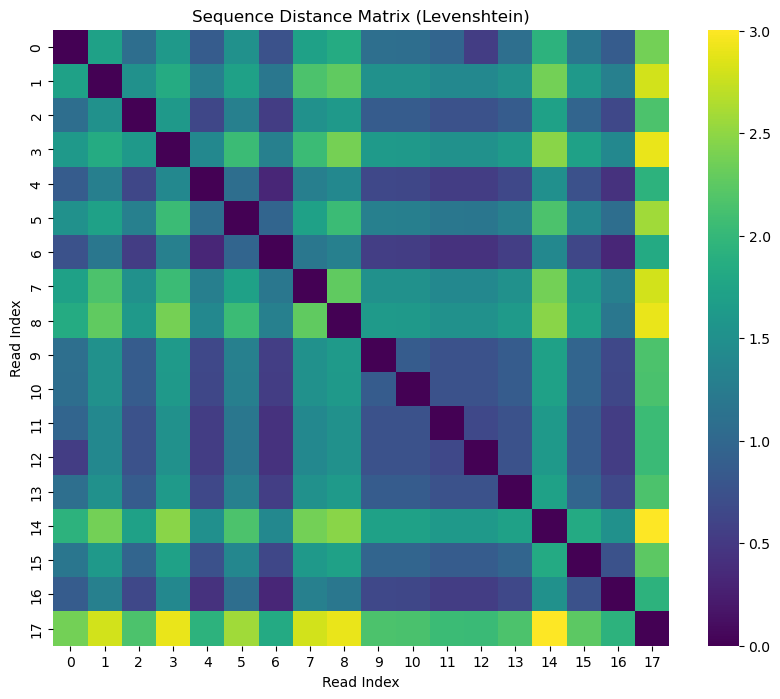

In [112]:
seqs = result_df2['Insert']

print(seqs)

seqs_scores_matrix = 100-process.cdist(seqs, seqs, scorer=fuzz.ratio, dtype=np.float32)
print(seqs_scores_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# cmap="YlGnBu_r" often looks good for similarity (darker = more similar)
# or "viridis" for standard distance
sns.heatmap(seqs_scores_matrix, annot=False, cmap="viridis", square=True)

plt.title("Sequence Distance Matrix (Levenshtein)")
plt.xlabel("Read Index")
plt.ylabel("Read Index")
plt.show()

In [18]:
import numpy as np
import math

def calc_mi_raw(col_a, col_b):
    """
    Calculates raw Shannon Mutual Information (in bits) for two columns.
    Standard 4x4 Contingency Table. No filters.
    """
    n = len(col_a)
    counts = np.zeros((4, 4), dtype=np.int32)
    marg_a = np.zeros(4, dtype=np.int32)
    marg_b = np.zeros(4, dtype=np.int32)
    
    valid_n = 0
    for i in range(n):
        u, v = col_a[i], col_b[i]
        if u > 3 or v > 3: continue
        counts[u, v] += 1
        marg_a[u] += 1
        marg_b[v] += 1
        valid_n += 1
        
    if valid_n == 0: return 0.0, counts

    mi = 0.0
    for r in range(4):
        p_r = marg_a[r] / valid_n
        if p_r == 0: continue
        
        for c in range(4):
            p_c = marg_b[c] / valid_n
            if p_c == 0: continue
            
            p_rc = counts[r, c] / valid_n
            if p_rc > 0:
                # Log2 for bits
                mi += p_rc * math.log2(p_rc / (p_r * p_c))
                
    return max(0.0, mi), counts

def run_test(scenario, n_members):
    print(f"\n=== SCENARIO: {scenario} (N={n_members}) ===")
    
    # 1. Generate Data
    col_1 = np.zeros(n_members, dtype=np.int8) # Default 'A' (0)
    col_2 = np.zeros(n_members, dtype=np.int8) # Default 'A' (0)
    
    if scenario == "Random Noise":
        # Two columns with independent errors (1 read has var in col1, another in col2)
        col_1[0] = 3 # Read 0 has T
        col_2[1] = 3 # Read 1 has T
        
    elif scenario == "Garbage Read":
        # One read has errors in BOTH columns (Perfect Correlation)
        col_1[0] = 3 
        col_2[0] = 3
        
    elif scenario == "Real Split":
        # Half the cluster differs
        half = n_members // 2
        col_1[:half] = 3 
        col_2[:half] = 3
        
    # 2. Calculate MI
    mi_score, table = calc_mi_raw(col_1, col_2)
    
    # 3. Print Details
    print(f"Column 1: {col_1}")
    print(f"Column 2: {col_2}")
    print("\nContingency Table (Rows=Col1, Cols=Col2):")
    print("      A  C  G  T")
    for r in range(4):
        row_str = " ".join([f"{table[r,c]:2d}" for c in range(4)])
        char = "ACGT"[r]
        print(f"  {char} [{row_str}]")
        
    print(f"\nRaw MI Score: {mi_score:.5f} bits")
    
    # Interpretation
    if mi_score < 0.01:
        print(">> RESULT: ZERO/NEGLIGIBLE (Correct for Noise)")
    else:
        print(">> RESULT: POSITIVE SIGNAL")

# --- RUN SCENARIOS ---
run_test("Random Noise", n_members=15)
run_test("Garbage Read", n_members=4)
run_test("Real Split", n_members=4)
run_test("Real Split", n_members=15)


=== SCENARIO: Random Noise (N=15) ===
Column 1: [3 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Column 2: [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]

Contingency Table (Rows=Col1, Cols=Col2):
      A  C  G  T
  A [13  0  0  1]
  C [ 0  0  0  0]
  G [ 0  0  0  0]
  T [ 1  0  0  0]

Raw MI Score: 0.00688 bits
>> RESULT: ZERO/NEGLIGIBLE (Correct for Noise)

=== SCENARIO: Garbage Read (N=4) ===
Column 1: [3 0 0 0]
Column 2: [3 0 0 0]

Contingency Table (Rows=Col1, Cols=Col2):
      A  C  G  T
  A [ 3  0  0  0]
  C [ 0  0  0  0]
  G [ 0  0  0  0]
  T [ 0  0  0  1]

Raw MI Score: 0.81128 bits
>> RESULT: POSITIVE SIGNAL

=== SCENARIO: Real Split (N=4) ===
Column 1: [3 3 0 0]
Column 2: [3 3 0 0]

Contingency Table (Rows=Col1, Cols=Col2):
      A  C  G  T
  A [ 2  0  0  0]
  C [ 0  0  0  0]
  G [ 0  0  0  0]
  T [ 0  0  0  2]

Raw MI Score: 1.00000 bits
>> RESULT: POSITIVE SIGNAL

=== SCENARIO: Real Split (N=15) ===
Column 1: [3 3 3 3 3 3 3 0 0 0 0 0 0 0 0]
Column 2: [3 3 3 3 3 3 3 0 0 0 0 0 0 0 0]

Contingency Table (R